In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib import font_manager

font_dirs = ["./"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    
sns.set( font = "Helvetica" )
api = wandb.Api()

data_name = 'dixit'

# Project is specified by <entity/project-name> please replace it with your project name here:
# runs = api.runs("kexinhuang/pert_gnn_simulation_" + data_name)
runs = api.runs("xuanhongchen-nus/dixit")

summary_list, config_list, name_list = [], [], []
for run in runs: 
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files 
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list
    })

In [9]:
### Make sure the run names match exactly with the wandb names!!

run = 6
#cpa_runs = ['CPA_' + str(i) for i in range(1, run)]
pertnet_runs = ['gears_seed' + str(i) for i in range(1, run)]
no_perturb_runs = ['no_perturb_seed' + str(i) for i in range(1, run)]
#linear_runs = ['Linear_' + str(i) for i in range(1, r un)]

In [12]:
res_df = runs_df[runs_df.name.isin(pertnet_runs + no_perturb_runs)]

In [25]:
for run in runs[:3]:
    print(run.name)
    print("config =", run.config)
    print("summary keys =", list(run.summary._json_dict.keys())[:10])
    print("-" * 50)

gears_seed2
config = {}
summary keys = ['_runtime', '_step', '_timestamp', 'test_combo_seen0_frac_opposite_direction_top20_non_dropout', 'test_combo_seen0_frac_sigma_below_1_non_dropout', 'test_combo_seen0_mse', 'test_combo_seen0_mse_de', 'test_combo_seen0_mse_top20_de_non_dropout', 'test_combo_seen0_pearson', 'test_combo_seen0_pearson_de']
--------------------------------------------------
gears_seed5
config = {}
summary keys = ['_runtime', '_step', '_timestamp', 'test_combo_seen0_frac_opposite_direction_top20_non_dropout', 'test_combo_seen0_frac_sigma_below_1_non_dropout', 'test_combo_seen0_mse', 'test_combo_seen0_mse_de', 'test_combo_seen0_mse_top20_de_non_dropout', 'test_combo_seen0_pearson', 'test_combo_seen0_pearson_de']
--------------------------------------------------
gears_seed4
config = {}
summary keys = ['_runtime', '_step', '_timestamp', 'test_combo_seen0_frac_opposite_direction_top20_non_dropout', 'test_combo_seen0_frac_sigma_below_1_non_dropout', 'test_combo_seen0_mse', 

In [13]:
res_df

,summary,config,name
0,"{'_runtime': 615, '_step': 15067, '_timestamp'...",{},gears_seed2
1,"{'_runtime': 631, '_step': 14992, '_timestamp'...",{},gears_seed5
2,"{'_runtime': 616, '_step': 14557, '_timestamp'...",{},gears_seed4
3,"{'_runtime': 628, '_step': 15487, '_timestamp'...",{},gears_seed3
4,"{'_runtime': 550, '_step': 14527, '_timestamp'...",{},gears_seed1
5,"{'_runtime': 91, '_step': 37, '_timestamp': 17...",{},no_perturb_seed2
6,"{'_runtime': 63, '_step': 37, '_timestamp': 17...",{},no_perturb_seed5
7,"{'_runtime': 86, '_step': 37, '_timestamp': 17...",{},no_perturb_seed4
8,"{'_runtime': 91, '_step': 37, '_timestamp': 17...",{},no_perturb_seed3
9,"{'_runtime': 89, '_step': 37, '_timestamp': 17...",{},no_perturb_seed1


In [14]:
def normalize_name(x):
    if x in pertnet_runs:
        return 'GEARS'
    else:
        return 'No-Perturb'

In [15]:
metrics = ['test_mse_top20_de_non_dropout', 'test_pearson_delta']
metrics_name_map = {'test_mse_top20_de_non_dropout': 'Top 20 DE MSE',
                   'test_pearson_delta': 'Pearson Correlation Across All Genes'}
out = {}
out['method'] = [normalize_name(i) for i in res_df.name.values]
for m in metrics:
    out[metrics_name_map[m]] = res_df.summary.apply(lambda x: x[m])
out = pd.DataFrame(out)

In [16]:
color_pal = {
'GEARS': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
'No-Perturb': (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)}

In [17]:
pal_order = [color_pal[i] for i in pd.DataFrame(out).method.unique()]

In [18]:
import numpy as np
normalize = np.mean(out[out.method == 'No-Perturb']['Top 20 DE MSE'])
out['Normalized MSE of Top 20 DE Genes'] = out['Top 20 DE MSE'].values/normalize

In [19]:
out

,method,Top 20 DE MSE,Pearson Correlation Across All Genes,Normalized MSE of Top 20 DE Genes
0,GEARS,0.028696,0.246054,0.319351
1,GEARS,0.041247,0.642753,0.459023
2,GEARS,0.020762,0.816642,0.231050
3,GEARS,0.030850,0.547163,0.343319
4,GEARS,0.023892,0.710997,0.265890
5,No-Perturb,0.076421,-0.014080,0.850469
6,No-Perturb,0.074477,0.036911,0.828826
7,No-Perturb,0.100729,-0.031800,1.120980
8,No-Perturb,0.120676,-0.045662,1.342970
9,No-Perturb,0.076986,-0.143567,0.856754


/var/folders/7r/gdt37d015_174c39qyzxkmf00000gn/T/ipykernel_79729/3530333462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.pointplot(x='method', y='Normalized MSE of Top 20 DE Genes',
/var/folders/7r/gdt37d015_174c39qyzxkmf00000gn/T/ipykernel_79729/3530333462.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(x='method', y='Normalized MSE of Top 20 DE Genes',
/var/folders/7r/gdt37d015_174c39qyzxkmf00000gn/T/ipykernel_79729/3530333462.py:20: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(


(0.2, 1.3)

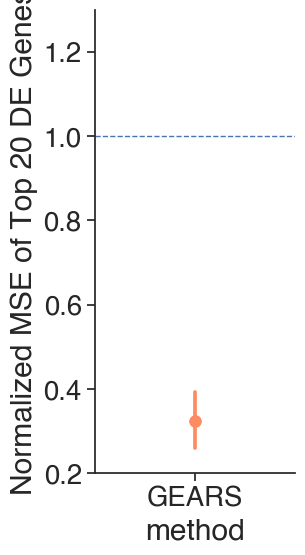

In [24]:
sns.set(rc={'figure.figsize':(3.5,6)})
sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font = "Helvetica", font_scale=1.8)

g = sns.pointplot(x='method', y='Normalized MSE of Top 20 DE Genes',
    data=pd.DataFrame(out), 
    order = ['GEARS'],
    palette=[color_pal['GEARS']],
    join=False,
    hue_order = ['GEARS'])
sns.set(rc={'figure.figsize': (3.5, 6)})
sns.set_theme(
    style="ticks",
    rc={"axes.facecolor": (0, 0, 0, 0)},
    font="Helvetica",
    font_scale=1.8
)

df = pd.DataFrame(out)

g = sns.pointplot(
    x='method',
    y='Normalized MSE of Top 20 DE Genes',
    data=df,
    order=['GEARS'],
    color=color_pal['GEARS'],
    join=False,
    errorbar=None
)

g.axhline(y=1, linestyle='--', linewidth=1)

sns.despine()
plt.tight_layout()
plt.ylim(0.2, 1.3)
